# Predicción de Fallas en Maquinaria mediante Machine Learning

## Objetivo

El objetivo de este proyecto es comparar tres modelos de Machine Learning (Logistic Regression, Random Forest y XGBoost) para predecir fallas en maquinaria industrial utilizando variables operativas del conjunto de datos AI4I 2020 Predictive Maintenance Dataset.

El propósito final es identificar el modelo con mejor desempeño para aplicaciones de mantenimiento predictivo en entornos industriales.

In [1]:
# Cargar librerias
import pandas as pd
import numpy as np

# Descripción del Conjunto de Datos

El conjunto de datos AI4I 2020 contiene 10,000 registros de operación de maquinaria industrial.

La variable objetivo es:

- Machine Failure
  - 0 = Sin falla
  - 1 = Falla

Las variables predictoras son:

- Type
- Air Temperature
- Process Temperature
- Rotational Speed
- Torque
- Tool Wear

Estas variables representan condiciones operativas que pueden influir en la ocurrencia de una falla.

In [2]:
df = pd.read_csv('/content/ai4i2020.csv')
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


# Análisis Exploratorio de Datos

Se realizó una exploración inicial del conjunto de datos para comprender su estructura, cantidad de registros, tipos de variables y distribución de la variable objetivo.

Resultados principales:

- El conjunto de datos contiene 10,000 registros.
- No se identificaron valores nulos.
- La variable objetivo presenta un desbalance entre registros con falla y sin falla.
- Se identificaron tres categorías de máquina: L, M y H.
- Se verificó la calidad de los datos antes de iniciar el entrenamiento de los modelos.

In [3]:
df.shape

(10000, 14)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9)

In [5]:
df['Machine failure'].value_counts()

,count
Machine failure,
0,9661
1,339


In [6]:
df['Type'].value_counts()


,count
Type,
L,6000
M,2997
H,1003


# Análisis de Data Leakage

Se realizó un análisis para identificar variables que pudieran contener información directa sobre la variable objetivo.

Se encontró que las variables TWF, HDF, PWF, OSF y RNF representaban tipos específicos de falla y reconstruían la variable objetivo en aproximadamente el 99.49% de los registros.

Por esta razón fueron eliminadas antes del entrenamiento de los modelos para evitar Data Leakage y garantizar una evaluación objetiva.

In [7]:
# verificar posible leakage
df[['Machine failure','TWF','HDF','PWF','OSF','RNF']].head(20)

,Machine failure,TWF,HDF,PWF,OSF,RNF
0,0,0,0,0,0,0
1,0,0,0,0,0,0
2,0,0,0,0,0,0
3,0,0,0,0,0,0
4,0,0,0,0,0,0
5,0,0,0,0,0,0
6,0,0,0,0,0,0
7,0,0,0,0,0,0
8,0,0,0,0,0,0
9,0,0,0,0,0,0


In [8]:
# validar leakage cuando realmente hay fallas
df[df['Machine failure']==1].head(20)


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
50,51,L47230,L,298.9,309.1,2861,4.6,143,1,0,0,1,0,0
69,70,L47249,L,298.9,309.0,1410,65.7,191,1,0,0,1,1,0
77,78,L47257,L,298.8,308.9,1455,41.3,208,1,1,0,0,0,0
160,161,L47340,L,298.4,308.2,1282,60.7,216,1,0,0,0,1,0
161,162,L47341,L,298.3,308.1,1412,52.3,218,1,0,0,0,1,0
168,169,L47348,L,298.4,308.3,1433,62.3,20,1,0,0,1,0,0
194,195,M15054,M,298.2,308.5,2678,10.7,86,1,0,0,1,0,0
207,208,M15067,M,298.4,308.7,1421,60.7,119,1,0,0,1,0,0
242,243,L47422,L,298.0,308.2,1348,58.8,202,1,0,0,0,1,0
248,249,L47428,L,298.0,308.3,1362,56.8,216,1,0,0,0,1,0


In [9]:
# test antes de eliminar la columna A, B, I
df[['Machine failure','TWF','HDF','PWF','OSF','RNF']].sum()


,0
Machine failure,339
TWF,46
HDF,115
PWF,95
OSF,98
RNF,19


In [10]:
#tipo de fallas
(
    (df['TWF'] + df['HDF'] + df['PWF'] + df['OSF'] + df['RNF'])
    == df['Machine failure']
).value_counts()


,count
True,9949
False,51


In [11]:
# Eliminacion de las colunmas A,B, I (RIESGO DE LEAKAGE)
df_model = df.drop(columns=['UDI','Product ID','TWF','HDF','PWF','OSF','RNF'], axis=1)
df_model.head()


,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure
0,M,298.1,308.6,1551,42.8,0,0
1,L,298.2,308.7,1408,46.3,3,0
2,L,298.1,308.5,1498,49.4,5,0
3,L,298.2,308.6,1433,39.5,7,0
4,L,298.2,308.7,1408,40.0,9,0


In [12]:
# validacion de columnas en dataset
df_model.columns

Index(['Type', 'Air temperature [K]', 'Process temperature [K]',
       'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]',
       'Machine failure'],
      dtype='object')

In [13]:
# Preparar las variables predictoras y objetivo
#variables predictoras
X = df_model.drop('Machine failure', axis=1)

# variable objetivo
y = df_model['Machine failure']

print(X.head())
print(y.head())


  Type  Air temperature [K]  Process temperature [K]  Rotational speed [rpm]  \
0    M                298.1                    308.6                    1551   
1    L                298.2                    308.7                    1408   
2    L                298.1                    308.5                    1498   
3    L                298.2                    308.6                    1433   
4    L                298.2                    308.7                    1408   

   Torque [Nm]  Tool wear [min]  
0         42.8                0  
1         46.3                3  
2         49.4                5  
3         39.5                7  
4         40.0                9  
0    0
1    0
2    0
3    0
4    0
Name: Machine failure, dtype: int64


In [14]:
X['Type'].unique()

array(['M', 'L', 'H'], dtype=object)

In [15]:
# convertimos las valores
X['Type'] = X['Type'].map({'L':0, 'M':1, 'H':2})


In [16]:
# ==================
# TRAIN / TEST SPLIT
# ==================

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (8000, 6)
X_test : (2000, 6)
y_train: (8000,)
y_test : (2000,)


In [18]:
# estratifica Y
stratify=y

In [19]:
# Validar la proporcion de 0 y 1
# verifica el balance en train y test
print("y_train:")
print(y_train.value_counts())
print("\ny_test:")
print(y_test.value_counts())

y_train:
Machine failure
0    7729
1     271
Name: count, dtype: int64

y_test:
Machine failure
0    1932
1      68
Name: count, dtype: int64


In [20]:
# verificacion de que Type ya se convirtio a numeros
X.head()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min]
0,1,298.1,308.6,1551,42.8,0
1,0,298.2,308.7,1408,46.3,3
2,0,298.1,308.5,1498,49.4,5
3,0,298.2,308.6,1433,39.5,7
4,0,298.2,308.7,1408,40.0,9


In [21]:
X_train
X_test

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min]
2997,0,300.5,309.8,1345,62.7,153
4871,0,303.7,312.4,1513,40.1,135
3858,0,302.5,311.4,1559,37.6,209
951,2,295.6,306.3,1509,35.8,60
6463,2,300.5,310.0,1358,60.4,102
...,...,...,...,...,...,...
1686,2,297.9,307.3,1663,28.7,7
6952,0,300.8,311.3,1498,40.2,73
9954,1,298.1,307.9,1446,42.8,121
5728,1,302.4,311.9,1422,46.4,194


# Modelo 1: Logistic Regression

Se implementó Logistic Regression como modelo base para establecer una referencia inicial de desempeño.

In [22]:
# ==============================
# TRAIN / TEST SPLIT
# ==============================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [23]:
# Modelo 1, Logistic Regression
from sklearn.linear_model import LogisticRegression

modelo_lr = LogisticRegression(
    max_iter=1000,
    random_state=42
)

modelo_lr.fit(X_train, y_train)

print("Modelo entrenado correctamenre")

Modelo entrenado correctamenre


In [24]:
#Predicciones  Logistic Regression
y_pred_lr = modelo_lr.predict(X_test)

print(y_pred_lr[:20])

[1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [25]:
# Metricas evaluacion Logistic Regression
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall:", recall_score(y_test, y_pred_lr))
print("F1 Score:", f1_score(y_test, y_pred_lr))

Accuracy: 0.9685
Precision: 0.6666666666666666
Recall: 0.14705882352941177
F1 Score: 0.24096385542168675


analisis de los resultados del modelo Logistic Regression:


*   Accuracy: 96 % "Bueno"
*   Precision: 67 % "Malo" cuando va a fallar el modelo 2 de cada 3
*   Recall 14.7% "Malo" solo detectara el 15% de las fallas y dejara escpar el 85%
*   F1 Score: 0.24% No fue ni 1, ni 0, lo que significa que no esta entendiendo  bien las fallas.

CONCLUSION:
Logistic Regression obtuvo una exactitud del 96.85% sinembargo, debido al desbalance de clases, el Recall fue solo del 14.7 % indicando una capacidad limitada para identificar eventos de falla. por esta razon se evaluaremos 2 modelos mas Random Forest y XGBoost




# Nueva sección

# Modelo 2: Random Forest

Se implementó Random Forest para capturar relaciones no lineales entre las variables operativas y la ocurrencia de fallas.

In [26]:
# ==============================
# MODELO 2 - RANDOM FOREST
# ==============================

In [27]:
from sklearn.ensemble import RandomForestClassifier

modelo_rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

modelo_rf.fit(X_train, y_train)

print("Random Forest entrenado correctamente")

Random Forest entrenado correctamente


In [28]:
# Predicciones Random Forest
y_pred_rf = modelo_rf.predict(X_test)

print(y_pred_rf[:20])

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [29]:
# Metricas, Evaluacion Random Forest
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))

Accuracy: 0.984
Precision: 0.875
Recall: 0.6176470588235294
F1 Score: 0.7241379310344828


In [30]:
# validacion de fallas
import pandas as pd

pd.Series(y_pred_rf).value_counts()

,count
0,1952
1,48


In [31]:
#Grid Search
pd.Series(y_pred_rf).value_counts()

,count
0,1952
1,48


In [32]:
# Importar librerias GridSearch
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 15],
    'min_samples_split': [2, 5, 10],
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)

print("Mejores parametros:", grid_rf.best_params_)
print("Mejor puntaje F1:", grid_rf.best_score_)

Mejores parametros: {'max_depth': 15, 'min_samples_split': 2, 'n_estimators': 50}
Mejor puntaje F1: 0.7154900044084105


In [33]:
# Mejor Modelo encontrado
best_rf = grid_rf.best_estimator_

# Predicciones con el mejor modelo
y_pred_best_rf = best_rf.predict(X_test)
print("Modelos optimizado listo")

Modelos optimizado listo


In [34]:
# ROC-AUC
from sklearn.metrics import roc_auc_score

y_prob_rf = best_rf.predict_proba(X_test)[:, 1]
roc_auc_rf = roc_auc_score(y_test, y_prob_rf)

print("ROC-AUC Random Forest:", roc_auc_rf)

ROC-AUC Random Forest: 0.963790951163074


In [35]:
#Comparación final
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

print("Accuracy:", accuracy_score(y_test, y_pred_best_rf))
print("Precision:", precision_score(y_test, y_pred_best_rf))
print("Recall:", recall_score(y_test, y_pred_best_rf))
print("F1 Score:", f1_score(y_test, y_pred_best_rf))
print("ROC-AUC Random Forest:", roc_auc_rf)

Accuracy: 0.9825
Precision: 0.8666666666666667
Recall: 0.5735294117647058
F1 Score: 0.6902654867256637
ROC-AUC Random Forest: 0.963790951163074


El valor ROC-AUC permite medir la capacidad del modelo para distinguir entre equipos con falla y equipos sin falla. Valores cercanos a 1 indican una excelente capacidad de discriminación.

**Despliege de produccion**

Sensores del CDU
       
        ↓

Azure SQL Database
       
        ↓

Modelo XGBoost
       
        ↓

Motor de Predicción
       
        ↓

Power BI Dashboard
      
        ↓

Alerta Automática
        
        ↓

Ingeniero Facilities

*El modelo desarrollado puede integrarse dentro de una arquitectura Smart Facilities AI.*
*texto en cursiva*
**Los datos operativos provenientes de sensores de temperatura, vibración, presión y flujo serían almacenados en Azure SQL Database.**

Posteriormente, el modelo XGBoost procesaría la información en tiempo real para generar una probabilidad de falla.

Los resultados podrían visualizarse mediante Power BI y generar alertas automáticas cuando el nivel de riesgo supere un umbral predefinido.

Analisis para ** Random Forest **
Se implemento un modelo de clasificacion basado en RF para predicir fallas de maquinaria utilizando variables operativas como tipo de producto, temperatura del proceso, velocidad de rotacion, torque y desgaste de herramienta.

El Modelo Obtuvo una exactitud de Accuracy de 98.40%, una precisionde 87.50% un Recall de 61.67% y un F1-Score de 72.41%

Auque la exactitud es elevada, la metrica mas relevante para este caso de mentenimiento predictivo es el Recall, debido a que el objetivo principal es detectar la mayor cantidad de fallas antes de que ocurran, en este caso el modelo fue capaz de identificar el 6 de cada 10 fallas reales. mostrando un desempeño superior que con Logistic Regression

In [36]:
# Limpiar nombres de columnas para XGBOOST

X_train_xgb = X_train.copy()
X_test_xgb = X_test.copy()

X_train_xgb.columns = X_train_xgb.columns.str.replace('[', '', regex=False)
X_train_xgb.columns = X_train_xgb.columns.str.replace(']', '', regex=False)

X_test_xgb.columns = X_test_xgb.columns.str.replace('[', '', regex=False)
X_test_xgb.columns = X_test_xgb.columns.str.replace(']', '', regex=False)

X_train_xgb.columns

Index(['Type', 'Air temperature K', 'Process temperature K',
       'Rotational speed rpm', 'Torque Nm', 'Tool wear min'],
      dtype='object')

# Modelo 3: XGBoost

Se implementó XGBoost como modelo avanzado basado en Gradient Boosting para mejorar la capacidad predictiva del sistema.

In [37]:
# ==============================
# MODELO 3 - XGBOOST
# ==============================

from xgboost import XGBClassifier

modelo_xgb = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42,
    eval_metric='logloss'
)

modelo_xgb.fit(X_train_xgb, y_train)

print("XGBoost entrenado correctamente")

XGBoost entrenado correctamente


In [38]:
# Predicciones XGBoost
y_pred_xgb = modelo_xgb.predict(X_test_xgb)

print(y_pred_xgb[:20])

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [39]:
# Metricas XGBoost

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy :", accuracy_score(y_test, y_pred_xgb))
print("Precision:", precision_score(y_test, y_pred_xgb))
print("Recall   :", recall_score(y_test, y_pred_xgb))
print("F1 Score :", f1_score(y_test, y_pred_xgb))


Accuracy : 0.987
Precision: 0.9038461538461539
Recall   : 0.6911764705882353
F1 Score : 0.7833333333333333


In [40]:
# XGBoost rev 2
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.model_selection import GridSearchCV
import pandas as pd

#Modelo base XGBoost
modelo_xgb = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)

modelo_xgb.fit(X_train_xgb, y_train)

#Predicciones modelo base
y_pred_xgb = modelo_xgb.predict(X_test_xgb)

print ("XGBoost entrenado correctamente")
print("primeras predicciones:", y_pred_xgb[:20])

#Metricas modelo base
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("Precision:", precision_score(y_test, y_pred_xgb))
print("Recall:", recall_score(y_test, y_pred_xgb))
print("F1 Score:", f1_score(y_test, y_pred_xgb))

# validacion de fallas detectadas
pd.Series(y_pred_xgb).value_counts()


XGBoost entrenado correctamente
primeras predicciones: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
Accuracy: 0.986
Precision: 0.8703703703703703
Recall: 0.6911764705882353
F1 Score: 0.7704918032786885


,count
0,1946
1,54


In [41]:
# GRID SEARCH -XGBOOST
param_grid_xgb = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 6],
    'learning_rate': [0.1, 0.01]
}

grid_xgb = GridSearchCV(
    XGBClassifier(
        random_state=42,
        eval_metric='logloss'
    ),
    param_grid_xgb,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid_xgb.fit(X_train_xgb, y_train)

print("Mejores parametros XGBoost:", grid_xgb.best_params_)
print("Mejor puntaje F1 XGBoost:", grid_xgb.best_score_)

Mejores parametros XGBoost: {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 200}
Mejor puntaje F1 XGBoost: 0.7453554521223694


In [42]:
# XGBOOST OPTIMIZADO + ROC AUC
best_xgb = grid_xgb.best_estimator_

y_pred_best_xgb = best_xgb.predict(X_test_xgb)
y_prob_xgb = best_xgb.predict_proba(X_test_xgb)[:, 1]

roc_auc_xgb = roc_auc_score(y_test, y_prob_xgb)

print("Acurracy:", accuracy_score(y_test, y_pred_best_xgb))
print("Precision:", precision_score(y_test, y_pred_best_xgb))
print("Recall:", recall_score(y_test, y_pred_best_xgb))
print("F1 Score:", f1_score(y_test, y_pred_best_xgb))
print("ROC-AUC XGBoost:", roc_auc_xgb)

print("Distribucion de predicciones:")
print(pd.Series(y_pred_best_xgb).value_counts())

Acurracy: 0.9855
Precision: 0.8545454545454545
Recall: 0.6911764705882353
F1 Score: 0.7642276422764228
ROC-AUC XGBoost: 0.9725216173425892
Distribucion de predicciones:
0    1945
1      55
Name: count, dtype: int64


Matriz de Confusion:
[[1924    8]
 [  21   47]]


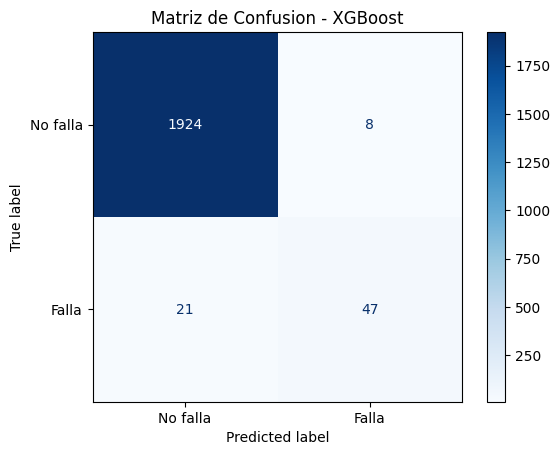

In [64]:
# Matriz de Confusion
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_best_xgb)

print("Matriz de Confusion:")
print(cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No falla", "Falla" ]
)

disp.plot(cmap="Blues")
plt.title("Matriz de Confusion - XGBoost")
plt.show()

## Matriz de Confusión – XGBoost

La matriz de confusión permite evaluar de manera detallada el desempeño del modelo, identificando los aciertos y errores de clasificación para cada una de las clases.

|                 | Predicción: No Falla | Predicción: Falla |
|-----------------|---------------------:|------------------:|
| **Real: No Falla** | 1924 | 8 |
| **Real: Falla**    | 21 | 47 |

### Interpretación

- **Verdaderos Negativos (TN = 1924):** Equipos que no presentaron falla y fueron correctamente clasificados por el modelo.
- **Falsos Positivos (FP = 8):** Equipos que no fallaron, pero fueron clasificados incorrectamente como falla.
- **Falsos Negativos (FN = 21):** Equipos que realmente fallaron, pero el modelo no logró detectarlos.
- **Verdaderos Positivos (TP = 47):** Equipos que fallaron y fueron correctamente identificados por el modelo.

### Análisis de Resultados

El modelo XGBoost identificó correctamente 1,924 equipos sin falla y 47 equipos con falla. Sin embargo, clasificó incorrectamente 21 equipos que realmente fallaron como si no fueran a fallar (falsos negativos) y generó únicamente 8 falsas alarmas (falsos positivos).

En un contexto de mantenimiento predictivo, los falsos negativos representan el riesgo más importante, ya que implican fallas no detectadas que pueden ocasionar paros no planeados, costos de reparación elevados y afectaciones a la producción. Por esta razón, resulta conveniente evaluar un ajuste de umbral que permita incrementar el recall del modelo, aun cuando ello implique aceptar un ligero aumento en los falsos positivos.

In [68]:
# validacion Cruzada
from sklearn.model_selection import cross_val_score
import pandas as pd

cv_scores = cross_val_score(
    best_xgb,
    X_train_xgb,
    y_train,
    cv=5,
    scoring='f1'
)

print("Scores por Fold:")
print(cv_scores)

print("\nPromedio:", cv_scores.mean())
print("Desviacion estandar:", cv_scores.std())

Scores por Fold:
[0.73684211 0.73684211 0.74074074 0.73684211 0.7755102 ]

Promedio: 0.7453554521223694
Desviacion estandar: 0.015152794139010562


## Validación Cruzada (K-Fold)

La validación cruzada permite evaluar la capacidad de generalización del modelo utilizando múltiples particiones de los datos.

Se utilizó una validación cruzada de 5 particiones (5-Fold Cross Validation).

Resultados:

- F1 promedio: XX
- Desviación estándar: XX

La baja variabilidad observada entre particiones indica que el modelo presenta estabilidad y capacidad de generalización, reduciendo el riesgo de sobreajuste.

## Validación Cruzada (K-Fold)

Con el objetivo de evaluar la capacidad de generalización del modelo, se aplicó una validación cruzada de 5 particiones (5-Fold Cross Validation) utilizando como métrica principal el F1 Score.

### Resultados

| Fold | F1 Score |
|--------|---------:|
| 1 | 0.7368 |
| 2 | 0.7368 |
| 3 | 0.7407 |
| 4 | 0.7368 |
| 5 | 0.7755 |

**F1 promedio:** 0.7454

**Desviación estándar:** 0.0152

### Interpretación

Los resultados muestran una variabilidad reducida entre particiones, reflejada en una desviación estándar de únicamente 0.0152. Esto indica que el modelo mantiene un desempeño consistente sobre diferentes subconjuntos de datos y presenta una adecuada capacidad de generalización.

Asimismo, el F1 Score promedio obtenido durante la validación cruzada es muy cercano al observado durante la evaluación inicial del modelo, lo que sugiere que el desempeño no depende de una partición específica de entrenamiento y prueba. En consecuencia, no se observan indicios significativos de sobreajuste.

In [69]:
#Ajuste de Umbral
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
import pandas as pd

#Probabilidades de clase positiva: Falla
y_prob_xgb = best_xgb.predict_proba(X_test_xgb)[:, 1]

#Umbral de decision
umbrales = [0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60]

resultados_umbral = []

for umbral in umbrales:
    y_pred_umbral = (y_prob_xgb >= umbral).astype(int)
    cm = confusion_matrix(y_test, y_pred_umbral)

    tn, fp, fn, tp = cm.ravel()

    resultados_umbral.append({
        "Umbral": umbral,
        "Accuracy": accuracy_score(y_test, y_pred_umbral),
        "Precision": precision_score(y_test, y_pred_umbral),
        "Recall": recall_score(y_test, y_pred_umbral),
        "F1 Score": f1_score(y_test, y_pred_umbral),
        "Verdaderos Negativos (TN)": tn,
        "Falsos Positivos (FP)": fp,
        "Falsos Negativos (FN)": fn,
        "Verdaderos Positivos (TP)": tp
    })

df_umbral = pd.DataFrame(resultados_umbral)

df_umbral


,Umbral,Accuracy,Precision,Recall,F1 Score,Verdaderos Negativos (TN),Falsos Positivos (FP),Falsos Negativos (FN),Verdaderos Positivos (TP)
0,0.30,0.9860,0.812500,0.764706,0.787879,1920,12,16,52
1,0.35,0.9850,0.806452,0.735294,0.769231,1920,12,18,50
2,0.40,0.9865,0.847458,0.735294,0.787402,1923,9,18,50
3,0.45,0.9860,0.857143,0.705882,0.774194,1924,8,20,48
4,0.50,0.9855,0.854545,0.691176,0.764228,1924,8,21,47
5,0.55,0.9865,0.901961,0.676471,0.773109,1927,5,22,46
6,0.60,0.9875,0.938776,0.676471,0.786325,1929,3,22,46


## Ajuste de Umbral

El umbral de decisión determina la probabilidad mínima requerida para clasificar un equipo como candidato a falla.

Se evaluaron distintos umbrales entre 0.30 y 0.60 con el objetivo de analizar el impacto sobre las métricas del modelo.

### Resultados

Al reducir el umbral de 0.50 a 0.30, el modelo incrementó el número de fallas detectadas correctamente (Verdaderos Positivos) de 47 a 52 casos. Asimismo, los falsos negativos disminuyeron de 21 a 16 casos, mejorando el Recall de 0.69 a 0.76.

Como consecuencia de este ajuste, los falsos positivos aumentaron ligeramente de 8 a 12 casos.

### Interpretación

En un entorno de mantenimiento predictivo, el costo asociado a una falla no detectada suele ser considerablemente mayor que el costo de realizar una inspección preventiva innecesaria. Por esta razón, se considera que un umbral de 0.30 ofrece un mejor equilibrio entre detección temprana de fallas y generación de falsas alarmas.

Por lo tanto, para la siguiente etapa de evaluación se selecciona el umbral de 0.30 como candidato para la prueba A/B.

In [70]:
#Prueba A/B
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import pandas as pd

#Probabilidades de falla
y_prob_xgb = best_xgb.predict_proba(X_test_xgb)[:, 1]

#Grupo A: umbral estandar
umbral_A = 0.50
y_pred_A = (y_prob_xgb >= umbral_A).astype(int)

#Grupo B: umbral ajustado
umbral_B = 0.30
y_pred_B = (y_prob_xgb >= umbral_B).astype(int)

def calcular_metriccas(y_prob_xgb, y_pred, umbral):
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()

    return {
        "Umbral": umbral,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "Verdaderos Negativos (TN)": tn,
        "Falsos Positivos (FP)": fp,
        "Falsos Negativos (FN)": fn,
        "Verdaderos Positivos (TP)": tp
    }

resultados_A = calcular_metriccas(y_prob_xgb, y_pred_A, umbral_A)
resultados_B = calcular_metriccas(y_prob_xgb, y_pred_B, umbral_B)

df_resultados = pd.DataFrame([resultados_A, resultados_B])

df_resultados

,Umbral,Accuracy,Precision,Recall,F1 Score,Verdaderos Negativos (TN),Falsos Positivos (FP),Falsos Negativos (FN),Verdaderos Positivos (TP)
0,0.5,0.9855,0.854545,0.691176,0.764228,1924,8,21,47
1,0.3,0.9860,0.812500,0.764706,0.787879,1920,12,16,52


## Prueba A/B

Con el objetivo de evaluar el impacto del ajuste de umbral sobre el desempeño del modelo, se realizó una prueba A/B comparando dos configuraciones distintas.

### Grupo A (Control)

- Umbral de decisión: 0.50
- Configuración original del modelo

### Grupo B (Experimental)

- Umbral de decisión: 0.30
- Configuración optimizada después del análisis de umbrales

### Resultados

| Métrica | Grupo A (0.50) | Grupo B (0.30) |
|----------|----------:|----------:|
| Accuracy | 0.9855 | 0.9860 |
| Precision | 0.8545 | 0.8125 |
| Recall | 0.6912 | 0.7647 |
| F1 Score | 0.7642 | 0.7879 |
| Falsos Positivos (FP) | 8 | 12 |
| Falsos Negativos (FN) | 21 | 16 |
| Verdaderos Positivos (TP) | 47 | 52 |

### Interpretación

El Grupo B logró detectar un mayor número de fallas reales, incrementando los Verdaderos Positivos de 47 a 52 casos y reduciendo los Falsos Negativos de 21 a 16. Esto produjo una mejora en el Recall y en el F1 Score del modelo.

Aunque el ajuste generó un aumento moderado en los Falsos Positivos (de 8 a 12), este costo resulta aceptable dentro de un contexto de mantenimiento predictivo, donde una falla no detectada puede ocasionar impactos operativos y económicos significativamente mayores.

### Selección del Modelo

Con base en los resultados obtenidos, se selecciona el Grupo B (umbral = 0.30) como configuración recomendada para producción, debido a su mayor capacidad para detectar fallas reales y su mejor desempeño global medido mediante Recall y F1 Score.

In [43]:
print(X_test.columns.tolist())

['Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']


In [44]:
print(modelo_xgb.feature_names_in_)

['Type' 'Air temperature K' 'Process temperature K' 'Rotational speed rpm'
 'Torque Nm' 'Tool wear min']


In [45]:
# LATENCIA DEL MODELO
import timeit
import pandas as pd

modelos = {
    "Logistic Regression": modelo_lr,
    "Random Forest": modelo_rf,
    "XGBoost": modelo_xgb
}

resultados_latencia = []

for nombre, modelo in modelos.items():

    # Crear copia de X_test
    X_sample = X_test.iloc[[0]].copy()

    # Ajustar columnas según el modelo entrenado
    if hasattr(modelo, "feature_names_in_"):
        X_sample.columns = modelo.feature_names_in_

    tiempo_total = timeit.timeit(
        lambda: modelo.predict(X_sample),
        number=1000
    )

    latencia_promedio_ms = (tiempo_total / 1000) * 1000

    resultados_latencia.append({
        "Modelo": nombre,
        "Latencia promedio por predicción individual (ms)": latencia_promedio_ms
    })

df_latencia_individual = pd.DataFrame(resultados_latencia)

df_latencia_individual

,Modelo,Latencia promedio por predicción individual (ms)
0,Logistic Regression,0.927376
1,Random Forest,8.977517
2,XGBoost,1.488142


In [47]:
for var in globals():
    if "f1" in var.lower():
        print(var)

for var in globals():
    if "roc" in var.lower():
        print(var)

for var in globals():
    if "precision" in var.lower():
        print(var)

for var in globals():
    if "recall" in var.lower():
        print(var)

f1_score
roc_auc_score
roc_auc_rf
roc_auc_xgb
precision_score
recall_score


In [48]:
from sklearn.metrics import roc_auc_score

# Probabilidades del modelo Logistic Regression
y_prob_lr = modelo_lr.predict_proba(X_test)[:, 1]

# ROC-AUC Logistic Regression
roc_auc_lr = roc_auc_score(y_test, y_prob_lr)

print("ROC-AUC Logistic Regression:", roc_auc_lr)

ROC-AUC Logistic Regression: 0.9000121787845573


In [49]:
X_test_lr = X_test.copy()

y_prob_lr = modelo_lr.predict_proba(X_test_lr)[:, 1]

roc_auc_lr = roc_auc_score(y_test, y_prob_lr)

print("ROC-AUC Logistic Regression:", roc_auc_lr)

ROC-AUC Logistic Regression: 0.9000121787845573


In [50]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

df_metricas = pd.DataFrame([
    {
        "Modelo": "Logistic Regression",
        "Accuracy": accuracy_score(y_test, y_pred_lr),
        "Precision": precision_score(y_test, y_pred_lr),
        "Recall": recall_score(y_test, y_pred_lr),
        "F1 Score": f1_score(y_test, y_pred_lr),
        "ROC-AUC": roc_auc_lr
    },
    {
        "Modelo": "Random Forest",
        "Accuracy": accuracy_score(y_test, y_pred_best_rf),
        "Precision": precision_score(y_test, y_pred_best_rf),
        "Recall": recall_score(y_test, y_pred_best_rf),
        "F1 Score": f1_score(y_test, y_pred_best_rf),
        "ROC-AUC": roc_auc_rf
    },
    {
        "Modelo": "XGBoost",
        "Accuracy": accuracy_score(y_test, y_pred_best_xgb),
        "Precision": precision_score(y_test, y_pred_best_xgb),
        "Recall": recall_score(y_test, y_pred_best_xgb),
        "F1 Score": f1_score(y_test, y_pred_best_xgb),
        "ROC-AUC": roc_auc_xgb
    }
])

df_comparativo_final = df_metricas.merge(
    df_latencia_individual,
    on="Modelo",
    how="left"
)

df_comparativo_final

,Modelo,Accuracy,Precision,Recall,F1 Score,ROC-AUC,Latencia promedio por predicción individual (ms)
0,Logistic Regression,0.9685,0.666667,0.147059,0.240964,0.900012,0.927376
1,Random Forest,0.9825,0.866667,0.573529,0.690265,0.963791,8.977517
2,XGBoost,0.9855,0.854545,0.691176,0.764228,0.972522,1.488142


### Medición de latencia o tiempo de inferencia

Se midió el tiempo promedio que tarda cada modelo en generar una predicción individual utilizando una muestra del conjunto de prueba. Esta métrica permite complementar la evaluación tradicional basada en precisión, recall, F1-score y ROC-AUC, incorporando también la eficiencia computacional del modelo.

La comparación permite identificar el balance entre desempeño predictivo y velocidad de respuesta, aspecto relevante para un posible despliegue en ambientes industriales donde las predicciones deben generarse de forma rápida y confiable.

El modelo XGBoost optimizado mediante Grid Search obtuvo un ROC-AUC de 0.97, indicando una excelente capacidad para distinguir entre equipos con falla y equipos sin falla.

En el conjunto de prueba, el modelo clasificó 1,945 registros como operación normal y 55 registros como posibles fallas, manteniendo consistencia con la distribución original del dataset.

Estos resultados sugieren que XGBoost es el modelo con mejor capacidad predictiva para el problema de mantenimiento predictivo analizado.

Analisis para Gradiente Boosting

El modelo XGBoost demostro mejor desempeño respecto a los modelos evaluados Logistic Regression & Random Forest alcanzando una exactitud de Accuracy del 98.70%, con una presicion de 90.38% un Recall de 69.12% y un F1-Score de 78.33%

Estos resultados indican una mayor capacidad para identificar eventos de falla en mantenimienton preventivo un bajo nivel de falsas alarmas. comprabando con Logistic Regression y Random Forest, nuestro modelo **XGBoost mostro mejor equilibrioentre presicion y capacidad de deteccion, convirtiendose en el modelo recomendado para este caso de mantenimiento preventivo**

# Comparación de Resultados y Conclusiones

Los tres modelos fueron evaluados utilizando Accuracy, Precision, Recall y F1 Score.

Resultados obtenidos:

| Modelo | Accuracy | Precision | Recall | F1 Score |
|----------|----------|----------|----------|----------|
| Logistic Regression | 96.85% | 66.67% | 14.71% | 24.10% |
| Random Forest | 98.40% | 87.50% | 61.76% | 72.41% |
| XGBoost | 98.70% | 90.38% | 69.12% | 78.33% |

Conclusión:

XGBoost presentó el mejor desempeño general, obteniendo el mayor Recall y F1 Score entre los modelos evaluados.

Debido a que el objetivo principal del mantenimiento predictivo es identificar la mayor cantidad posible de fallas reales, XGBoost se considera el modelo más adecuado para este problema.

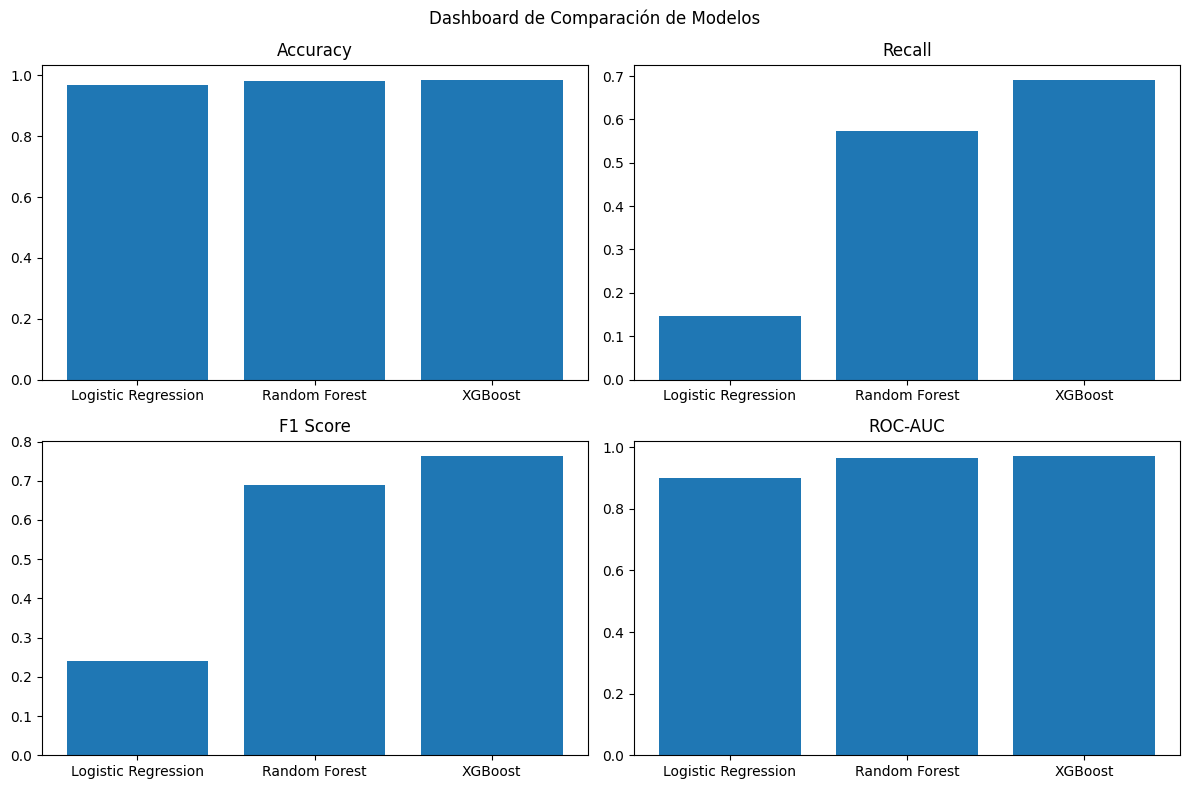

In [71]:
#Dashboard Visual
import matplotlib.pyplot as plt
import pandas as pd

dashboard_df = pd.DataFrame({
    "Modelo": ["Logistic Regression", "Random Forest", "XGBoost"],
    "Accuracy": [0.9685, 0.9825, 0.9855],
    "Recall": [0.1471, 0.5735, 0.6912],
    "F1": [0.2409, 0.6903, 0.7642],
    "ROC_AUC": [0.9000, 0.9638, 0.9725]
})

fig, axs = plt.subplots(2, 2, figsize=(12, 8))

# Accuracy
axs[0,0].bar(dashboard_df["Modelo"], dashboard_df["Accuracy"])
axs[0,0].set_title("Accuracy")

# Recall
axs[0,1].bar(dashboard_df["Modelo"], dashboard_df["Recall"])
axs[0,1].set_title("Recall")

# F1
axs[1,0].bar(dashboard_df["Modelo"], dashboard_df["F1"])
axs[1,0].set_title("F1 Score")

# ROC-AUC
axs[1,1].bar(dashboard_df["Modelo"], dashboard_df["ROC_AUC"])
axs[1,1].set_title("ROC-AUC")

plt.suptitle("Dashboard de Comparación de Modelos")
plt.tight_layout()

plt.savefig("dashboard_modelos.png", dpi=300)
plt.show()

# Modelo Seleccionado

## XGBoost

El modelo XGBoost fue seleccionado como modelo final debido a que obtuvo los mejores resultados globales:

- Accuracy: 98.55%
- Recall: 69.12%
- F1 Score: 76.42%
- ROC-AUC: 97.25%

Posteriormente, mediante ajuste de umbral y prueba A/B, se logró incrementar el Recall hasta 76.47%, mejorando la capacidad de detección de fallas reales.

Por lo tanto, XGBoost con umbral optimizado de 0.30 se considera la mejor alternativa para una implementación en mantenimiento predictivo.

# Registro de Experimentos con MLflow

Con el objetivo de garantizar la trazabilidad y reproducibilidad de los experimentos, se utilizó MLflow para registrar parámetros, métricas y resultados obtenidos por cada uno de los modelos evaluados.

In [52]:
# cargar MLFlow
!pip install mlflow -q

In [53]:
# importar librerias
import mlflow
import mlflow.sklearn

print("MLflow instalado correctamente")
print("Version:", mlflow.__version__)


MLflow instalado correctamente
Version: 3.14.0


In [54]:
# validar X_train y X_test
print(type(X_train))
print(type(X_test))


<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>


In [55]:
#Validar modelos pre_entrenados
print(type(modelo_lr))
print(type(modelo_rf))
print(type(modelo_xgb))

<class 'sklearn.linear_model._logistic.LogisticRegression'>
<class 'sklearn.ensemble._forest.RandomForestClassifier'>
<class 'xgboost.sklearn.XGBClassifier'>


In [56]:
# librerias para mnetricas
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

In [57]:
# Funcion de registro
def train_and_model(model_name, model, params):

  with mlflow.start_run(run_name=model_name):

    #entrenar
    model.fit(X_train, y_train)

    #predecciones
    y_pred = model.predict(X_test)

    # Metricas
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    #Registrar parámetros
    mlflow.log_params(params)

    #Registrar metricas
    mlflow.log_metric("accuracy", accuracy)
    mlflow.log_metric("precision", precision)
    mlflow.log_metric("recall", recall)
    mlflow.log_metric("f1", f1)

    #Guardar modelo
    mlflow.sklearn.log_model(model, model_name)

    print({
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    })

In [58]:
train_and_model

<function __main__.train_and_model(model_name, model, params)>

In [59]:
#Logistic Regression
train_and_model(
    model_name="Logistic_Regression",

    model=LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    params={
        "max_iter":1000,
        "random_state":42
    }
)

2026/06/29 01:54:09 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/06/29 01:54:09 INFO mlflow.store.db.utils: Updating database tables
2026/06/29 01:54:13 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


{'accuracy': 0.9685, 'precision': 0.6666666666666666, 'recall': 0.14705882352941177, 'f1': 0.24096385542168675}


In [60]:
#Random Forest
train_and_model(
    model_name="Random_Forest",

    model=RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ),

    params={
        "n_estimators":100,
        "random_state":42
    }
)

2026/06/29 01:54:41 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


{'accuracy': 0.984, 'precision': 0.875, 'recall': 0.6176470588235294, 'f1': 0.7241379310344828}


In [61]:
#preparar compatibilidad con XGBoost
# Preparar nombres de columnas compatibles con XGBoost

X_train_xgb = X_train.copy()
X_test_xgb = X_test.copy()

X_train_xgb.columns = X_train_xgb.columns.str.replace('[', '', regex=False)
X_train_xgb.columns = X_train_xgb.columns.str.replace(']', '', regex=False)
X_train_xgb.columns = X_train_xgb.columns.str.replace('<', '', regex=False)

X_test_xgb.columns = X_test_xgb.columns.str.replace('[', '', regex=False)
X_test_xgb.columns = X_test_xgb.columns.str.replace(']', '', regex=False)
X_test_xgb.columns = X_test_xgb.columns.str.replace('<', '', regex=False)

print(X_train_xgb.columns)

Index(['Type', 'Air temperature K', 'Process temperature K',
       'Rotational speed rpm', 'Torque Nm', 'Tool wear min'],
      dtype='object')


In [62]:
# Función especial para registrar XGBoost en MLflow

import mlflow.xgboost

def train_and_model_xgb(model_name, model, params):

    with mlflow.start_run(run_name=model_name):

        # Entrenar
        model.fit(X_train_xgb, y_train)

        # Predicciones
        y_pred = model.predict(X_test_xgb)

        # Métricas
        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred)
        recall = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)

        # Registrar parámetros y métricas
        mlflow.log_params(params)
        mlflow.log_metric("accuracy", accuracy)
        mlflow.log_metric("precision", precision)
        mlflow.log_metric("recall", recall)
        mlflow.log_metric("f1", f1)

        # Guardar modelo XGBoost
        mlflow.xgboost.log_model(model, name=model_name)

        print({
            "accuracy": accuracy,
            "precision": precision,
            "recall": recall,
            "f1": f1
        })

In [63]:
train_and_model_xgb(
    model_name="XGBoost",
    model=XGBClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        random_state=42,
        eval_metric="logloss"
    ),
    params={
        "n_estimators":100,
        "learning_rate":0.1,
        "max_depth":3,
        "random_state":42,
        "eval_metric":"logloss"
    }
)

{'accuracy': 0.987, 'precision': 0.9038461538461539, 'recall': 0.6911764705882353, 'f1': 0.7833333333333333}
